# SZ3 + model  vs  SPERR — PSNR vs Compression Ratio

Compare our **SZ3 + neural-residual** pipeline against **SPERR** (a wavelet compressor) across four datasets, one figure per dataset:

| Dataset | Target field(s) | Model params | Aux input |
|---|---|---|---|
| NYX 512³ | baryon density, temperature, dark matter density | 30k | other NYX fields |
| Miranda 1024³ | single field | 240k | — |
| Hurricane 100×500×500 | CLOUD | 6k | PRECIP,P,TC,U,V,W |
| Magnetic 512³ | single field | 30k | — |

Each curve sweeps the error bound to span a range of CR.  **SZ3 + model** stores the target's SZ3 stream + the model (bf16); **aux fields are raw side-info, not charged to CR** (NYX/Hurricane convention).  **SPERR** is standalone (its own bitstream) matched to each SZ3 point's PSNR (compare CR at equal quality); its PSNR is recomputed from the decompressed volume with the same formula.

In [1]:
import os, sys, time, subprocess
import numpy as np
import matplotlib.pyplot as plt
import torch

SPERR_BIN    = "/home/sam/Halo_Finder/SPERR/build/bin/sperr3d"
SZ3_LIB      = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
PYSZ_PATH    = "/home/sam/Data_Compression/SZ3/tools/pysz"
SCRIPTS_PATH = "/home/sam/Halo_Finder/Final_design/base_script"
for p in (PYSZ_PATH, SCRIPTS_PATH):
    if p not in sys.path:
        sys.path.append(p)

import importlib, bg_stage
importlib.reload(bg_stage)
from pysz import SZ
from bg_stage import train_bg_only, run_bg_inference, unwrap_bg_model
from experiment import build_bg_only_cfg, estimate_bg_model_param_bytes
from bg_shard import pick_bg_h_under_budget

device    = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sz_engine = SZ(SZ3_LIB)
BYTES_PER_PARAM = 2          # model weights stored as bf16
SEED = 17   # shared seed: NeurLZ + BG pipeline use the same SEED
import random as _random
def set_seed(s=SEED):
    torch.manual_seed(s); np.random.seed(s); _random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
DETERMINISTIC = False   # True = bit-exact reproducible (cuDNN deterministic convs, ~3-4x slower); seed is fixed either way
torch.backends.cudnn.benchmark = not DETERMINISTIC; torch.backends.cudnn.deterministic = DETERMINISTIC
set_seed(SEED)

def compute_psnr(x_true, x_hat, drange):
    mse = float(np.mean((np.asarray(x_true, np.float64) - np.asarray(x_hat, np.float64)) ** 2))
    return 100.0 if mse == 0 else 20.0 * np.log10(drange) - 10.0 * np.log10(mse)

def bg_h_for_params(budget, shape, n_fields):
    """Largest bg_h whose split-bands model fits the param budget."""
    h, est = pick_bg_h_under_budget(int(budget), shape=shape, n_fields=int(n_fields),
                                    bg_arch="spatial", h_candidates=list(range(3, 256)))
    return int(h)

def run_sperr(data_file, target_gt, shape, drange, target_psnr):
    """SPERR at a target PSNR.  Returns (CR, PSNR, recon, nbytes): the decompressed
    volume (for the SPERR+model curve) and the bitstream size.  PSNR is recomputed."""
    W, H, D = shape[2], shape[1], shape[0]          # SPERR wants fastest-varying first
    tag = np.random.randint(1 << 30)
    bit = f"/tmp/sperr_{tag}.bit"; rec = f"/tmp/sperr_{tag}.dec.f32"
    subprocess.run([SPERR_BIN, "-c", "--ftype", "32",
                    "--dims", str(W), str(H), str(D), "--psnr", f"{float(target_psnr):.4f}",
                    "--bitstream", bit, data_file], capture_output=True, text=True)
    if not os.path.exists(bit):
        return None, None, None, None
    nbytes = os.path.getsize(bit)
    subprocess.run([SPERR_BIN, "-d", "--decomp_f", rec, bit], capture_output=True, text=True)
    cr = psnr = recon = None
    if os.path.exists(rec):
        recon = np.fromfile(rec, dtype=np.float32).reshape(shape)
        psnr  = compute_psnr(target_gt, recon, drange)
        cr    = (int(np.prod(shape)) * 4) / nbytes
    for f in (bit, rec):
        if os.path.exists(f):
            os.remove(f)
    return cr, psnr, recon, nbytes

print("Setup ready | device:", device)

Setup ready | device: cuda:0


In [2]:
import io, contextlib

# ── Two-phase BO (per-rel LR autotune), applied to EVERY bench_field call ──────
# Phase 1: cheap LR sweep on a strided slice subsample -> best LR by proxy PSNR.
# Phase 2: full residual training at that LR (the existing _train_residual path).
# Set BO_ENABLE=False to fall back to the fixed `lr` argument.
BO_ENABLE          = True
BO_N_LR            = 10
BO_LR_MIN          = 1e-4
BO_LR_MAX          = 3e-3          # ceiling: this BG model + freq-loss diverges above ~3e-3
BO_LR_LIST         = [float(x) for x in np.logspace(np.log10(BO_LR_MIN), np.log10(BO_LR_MAX), BO_N_LR)]
BO_PHASE1_EPOCHS   = 8
BO_MAX_TUNE_SLICES = 32            # cap Phase-1 slices so it stays cheap on big volumes
BO_MIN_GAIN_DB     = 0.30          # an LR must beat the base by this (proxy) to be used at all
BO_LR_TIE_DB       = 0.30          # within this of the best proxy -> pick the LOWEST (most stable) LR
BO_DIR_TIE_DB      = 0.50          # axes within this of the best gain -> pick the LONGEST (most slices)
ADD_SLAB           = True          # also train a 2.5D slab2d model (K neighboring slices) per dataset
SLAB_K             = 7             # number of stacked slices for the 2.5D model
BG_USE_AUX         = False         # False = run the BG pipeline (2D + slab) target-only, no aux,
                                   #         to match NeurLZ's single-field setup (set True to use aux)
BO_SEARCH_DIRECTION = True         # also search the slicing axis (0/1/2); False = axis 0 only
_DIR_FWD = {0: (0, 1, 2), 1: (1, 0, 2), 2: (2, 0, 1)}   # bring axis k to the front (= slicing axis)
def _perm_view(a, k):
    return np.transpose(np.asarray(a), _DIR_FWD[k])                      # view (Phase-2 permute)
def _take_perm(a, k, idx):                                              # small copy (Phase-1 proxy)
    return np.ascontiguousarray(np.transpose(np.take(np.asarray(a, np.float32), idx, axis=k), _DIR_FWD[k]))

def _fmt(x):
    return f"{x:6.1f}" if x is not None else "  n/a "

def bench_field(name, target_gt, target_file, aux_list, shape, rel_errs,
                param_budget, epochs, lr=1e-3, sperr_psnr_offset=8.0,
                sperr_extra_span=0.0, sperr_n_extra=0, full_slice=False, full_slice_axis=0,
                bg_low_w=0.2, bg_mid_w=0.5, bg_high_w=1.0):
    """Run SZ3, SPERR, and SZ3+model across rel_errs for one target field.
    aux_list = raw (uncompressed) side-info fields; NOT charged to CR."""
    target_gt = np.asarray(target_gt, np.float32)
    if not BG_USE_AUX:                 # target-only: BG pipeline drops aux (NeurLZ is single-field anyway)
        aux_list = []
    drange    = float(target_gt.max() - target_gt.min())
    n_fields  = 1 + len(aux_list)
    bg_h      = bg_h_for_params(param_budget, shape, n_fields)
    n_params, nn_bytes = estimate_bg_model_param_bytes(
        n_fields=n_fields, shape=shape, bg_arch="spatial", bg_h=bg_h,
        dtype_bytes=BYTES_PER_PARAM)
    depth, patch = shape[0], shape[2]
    orig_bytes   = int(np.prod(shape)) * 4
    print(f"[{name}] budget {param_budget:,} -> bg_h={bg_h} (~{n_params:,} params, "
          f"{nn_bytes/1e3:.1f} KB) | n_fields={n_fields} | drange={drange:.3g}")
    neurlz_features = None
    if ADD_NEURLZ:
        _nlz_nf = 1 if globals().get("NEURLZ_SINGLE_FIELD", False) else n_fields
        neurlz_features = (_neurlz_features_for_params(n_params, _nlz_nf)
                           if NEURLZ_FEATURES == "match" else NEURLZ_FEATURES)
        print(f"[{name}] NeurLZ BasicUNet features={tuple(neurlz_features)} "
              f"(~{_basicunet_nparams(neurlz_features, _nlz_nf):,} params, in_ch={_nlz_nf})")

    sz3   = {"CR": [], "PSNR": []}; pipe       = {"CR": [], "PSNR": []}
    sperr = {"CR": [], "PSNR": []}; sperr_pipe = {"CR": [], "PSNR": []}
    neurlz = {"CR": [], "PSNR": []}; slab = {"CR": [], "PSNR": []}

    def _phase1_best(base_recon, base_rel):
        """Phase-1 BO over (slicing axis, lr). For each axis it permutes a small slice
        subsample so that axis becomes the depth, sweeps lr, and scores the proxy PSNR
        gain over the base. Returns (best_axis, best_lr); falls back to axis 0 + fixed lr
        when nothing improves. patch = min(plane dims) so no orientation overflows."""
        if not BO_ENABLE:
            return (full_slice_axis if full_slice else 0), lr
        full_shape = np.asarray(target_gt).shape
        axes = [full_slice_axis] if full_slice else ([0, 1, 2] if BO_SEARCH_DIRECTION else [0])
        results = {}
        for k in axes:
            Dk = int(full_shape[k])
            n_tune = int(min(Dk, max(8, BO_MAX_TUNE_SLICES)))
            idx = np.linspace(0, Dk - 1, n_tune).astype(int)
            tgt_t  = _take_perm(target_gt, k, idx)
            base_t = _take_perm(base_recon, k, idx)
            aux_t  = [_take_perm(a, k, idx) for a in aux_list]
            Xs_t, Xps_t = [tgt_t] + aux_t, [base_t] + aux_t
            nz, hh, ww = tgt_t.shape
            patch_d = int(min(hh, ww))
            dr_t = float(tgt_t.max() - tgt_t.min()) or 1.0
            base_p = compute_psnr(tgt_t, base_t, dr_t)
            scores = []
            for cand in BO_LR_LIST:
                cfg = build_bg_only_cfg(
                    X_target=Xs_t[0], Xps=Xps_t, max_train_time=1e9, bg_h=bg_h, roi_h=4,
                    epochs=int(BO_PHASE1_EPOCHS), steps_per_epoch=nz, bg_patch_size=patch_d,
                    bg_batch=1, lr=float(cand), bg_freq_weight=1.0, bg_fft_phase_weight=1.0,
                    bg_freq_warmup_epochs=1, bg_field_norm="zscore")
                cfg.bg_arch = "spatial"; cfg.bg_split_mode = "three"; cfg.bg_split_bands = True
                cfg.bg_split_sigma = 0.12; cfg.bg_sigma_low = 0.08; cfg.bg_sigma_mid = 0.18
                cfg.bg_low_weight = bg_low_w; cfg.bg_mid_weight = bg_mid_w; cfg.bg_high_weight = bg_high_w
                cfg.bg_cr_rel_err = float(base_rel); cfg.bg_gpu_sampling = True; cfg.seed = SEED; cfg.bg_full_slice = full_slice; cfg.bg_cudnn_benchmark = not DETERMINISTIC; cfg.bg_cudnn_deterministic = DETERMINISTIC
                def evt(m, _c=cfg):
                    xh = run_bg_inference(unwrap_bg_model(m), Xs_t, Xps_t, _c, float(base_rel))
                    return compute_psnr(tgt_t, xh, dr_t), 0.0
                with contextlib.redirect_stdout(io.StringIO()):
                    m, _ = train_bg_only(Xs=Xs_t, Xps=Xps_t, device=device, cfg=cfg, evaluator=evt)
                    p = compute_psnr(tgt_t, run_bg_inference(unwrap_bg_model(m), Xs_t, Xps_t, cfg, float(base_rel)), dr_t)
                del m
                torch.cuda.empty_cache() if torch.cuda.is_available() else None
                scores.append((cand, p))
            improving = [(c, p) for c, p in scores if (p - base_p) > BO_MIN_GAIN_DB]
            if improving:
                bp = max(p for _, p in improving)
                bl = min(c for c, p in improving if bp - p <= BO_LR_TIE_DB)
            else:
                bp, bl = max(p for _, p in scores), lr
            results[k] = (bl, bp, bp - base_p)
            print(f"  [BO] band={base_rel:.1e} axis{k}: {nz}x{hh}x{ww} patch{patch_d} "
                  f"base={base_p:.2f} -> lr={bl:.0e} proxy={bp:.2f} gain={bp-base_p:+.2f} | "
                  + " ".join(f"{c:.0e}:{p:.1f}" for c, p in scores))
        best_gain = max(results[k][2] for k in axes)
        if best_gain <= BO_MIN_GAIN_DB:
            print(f"  [BO] => no direction gains >{BO_MIN_GAIN_DB}dB -> axis0, fixed lr={lr:.1e}")
            return (full_slice_axis if full_slice else 0), lr
        # the equal-slice proxy can't see that a longer axis gives more 2-D training slices,
        # so among axes within BO_DIR_TIE_DB of the best gain, prefer the LONGEST one.
        near = [k for k in axes if best_gain - results[k][2] <= BO_DIR_TIE_DB]
        best_k = max(near, key=lambda k: (full_shape[k], -k))
        print(f"  [BO] => PICK axis{best_k} (depth={full_shape[best_k]}; near-best {{ {', '.join(f'{k}:{full_shape[k]}' for k in near)} }}) "
              f"lr={results[best_k][0]:.1e} gain={results[best_k][2]:+.2f}")
        return best_k, results[best_k][0]

    # Train the neural residual model on a base reconstruction, sliced along the BO-chosen
    # axis; output is clamped within `base_rel` * range of the base.
    def _train_residual(base_recon, base_rel):
        best_k, use_lr = _phase1_best(base_recon, base_rel)
        Xs0  = [target_gt] + aux_list
        Xps0 = [np.ascontiguousarray(base_recon, np.float32)] + aux_list
        if best_k == 0:
            Xs, Xps = Xs0, Xps0
        else:                                            # reorient so axis best_k is depth
            Xs  = [np.ascontiguousarray(_perm_view(a, best_k)) for a in Xs0]
            Xps = [np.ascontiguousarray(_perm_view(a, best_k)) for a in Xps0]
        dep_d   = int(Xs[0].shape[0])
        patch_d = int(min(Xs[0].shape[1], Xs[0].shape[2]))
        cfg = build_bg_only_cfg(
            X_target=Xs[0], Xps=Xps, max_train_time=1e9, bg_h=bg_h, roi_h=4,
            epochs=epochs, steps_per_epoch=dep_d, bg_patch_size=patch_d, bg_batch=1, lr=use_lr,
            bg_freq_weight=0.5, bg_fft_phase_weight=0.5, bg_freq_warmup_epochs=1,
            bg_field_norm="zscore")
        cfg.bg_arch = "spatial"; cfg.bg_split_mode = "three"; cfg.bg_split_bands = True
        cfg.bg_split_sigma = 0.12; cfg.bg_sigma_low = 0.08; cfg.bg_sigma_mid = 0.18
        cfg.bg_low_weight = bg_low_w; cfg.bg_mid_weight = bg_mid_w; cfg.bg_high_weight = bg_high_w
        cfg.bg_cr_rel_err = float(base_rel)
        cfg.bg_gpu_sampling = True
        cfg.seed = SEED
        cfg.bg_full_slice = full_slice   # wpx: whole 256x2048 planes
        cfg.bg_cudnn_benchmark = not DETERMINISTIC; cfg.bg_cudnn_deterministic = DETERMINISTIC
        def ev(model, c=cfg, Xs=Xs, Xps=Xps, r=base_rel):
            return compute_psnr(Xs[0], run_bg_inference(model, Xs, Xps, c, float(r)), drange), 0.0
        model, _hist = train_bg_only(Xs=Xs, Xps=Xps, device=device, cfg=cfg, evaluator=ev)
        bg_train_time = float(_hist["time"][-1]) if _hist.get("time") else float("nan")
        p = compute_psnr(Xs[0], run_bg_inference(model, Xs, Xps, cfg, float(base_rel)), drange)
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        return p, bg_train_time, best_k

    # ── SZ3  and  SZ3 + model ── (rel sweep; CR moves with the SZ3 bound)
    for rel in rel_errs:
        b, _   = sz_engine.compress(target_gt, 1, 0, float(rel), 0)
        sz_len = len(b)
        xq     = sz_engine.decompress(b, shape, np.float32)
        p_sz3  = compute_psnr(target_gt, xq, drange); cr_sz3 = orig_bytes / sz_len
        sz3["CR"].append(cr_sz3); sz3["PSNR"].append(p_sz3)
        p_pipe, bg_time, bg_axis = _train_residual(xq, rel)
        cr_pipe = orig_bytes / (sz_len + nn_bytes)
        pipe["CR"].append(cr_pipe); pipe["PSNR"].append(p_pipe)
        print(f"  rel={rel:.0e} | SZ3 {cr_sz3:6.1f}x/{p_sz3:5.1f}dB | "
              f"SZ3+model {cr_pipe:6.1f}x/{p_pipe:5.1f}dB (+{p_pipe-p_sz3:.1f})")
        if ADD_NEURLZ:
            p_nlz, nlz_params, nlz_time, nlz_eps = run_neurlz(
                target_gt, xq, aux_list, shape, drange, rel,
                int(epochs * NEURLZ_EPOCH_MULT), neurlz_features, time_budget=bg_time, slice_axis=bg_axis)
            cr_nlz = orig_bytes / (sz_len + nlz_params * BYTES_PER_PARAM)
            neurlz["CR"].append(cr_nlz); neurlz["PSNR"].append(p_nlz)
            print(f"           SZ3+NeurLZ {cr_nlz:6.1f}x/{p_nlz:5.1f}dB (+{p_nlz-p_sz3:.1f}) [{nlz_params:,}p]"
                  f" | BG {epochs}ep {bg_time:.1f}s ≈ NeurLZ {nlz_time:.1f}s/{nlz_eps}ep")
        if ADD_SLAB:                                   # 2.5D: stack K neighbor slices -> cross-slice context
            Xs_s  = [target_gt] + aux_list
            Xps_s = [np.ascontiguousarray(xq, np.float32)] + aux_list
            _sp = int(min(shape[1], shape[2]))   # full in-plane slice (slab2d infers full slices)
            cfg_s = build_bg_only_cfg(
                X_target=Xs_s[0], Xps=Xps_s, max_train_time=float(bg_time), bg_h=bg_h, roi_h=4,
                epochs=100000, steps_per_epoch=256, bg_patch_size=_sp, bg_batch=1, lr=lr,  # ISO-TIME: train for bg_time s (== 2D pipe == NeurLZ)
                bg_freq_weight=0.5, bg_fft_phase_weight=0.5, bg_freq_warmup_epochs=1, bg_field_norm="zscore")
            cfg_s.bg_arch="slab2d"; cfg_s.bg_slab_k=int(SLAB_K)
            cfg_s.bg_split_mode="three"; cfg_s.bg_split_bands=True
            cfg_s.bg_split_sigma=0.12; cfg_s.bg_sigma_low=0.08; cfg_s.bg_sigma_mid=0.18
            cfg_s.bg_cr_rel_err=float(rel); cfg_s.bg_gpu_sampling=True; cfg_s.seed=SEED
            cfg_s.bg_low_weight=bg_low_w; cfg_s.bg_mid_weight=bg_mid_w; cfg_s.bg_high_weight=bg_high_w
            cfg_s.bg_cudnn_benchmark=not DETERMINISTIC; cfg_s.bg_cudnn_deterministic=DETERMINISTIC
            set_seed(SEED)
            def _evs(m, c=cfg_s, Xs=Xs_s, Xps=Xps_s, r_=rel):
                return compute_psnr(Xs[0], run_bg_inference(m, Xs, Xps, c, float(r_)), drange), 0.0
            m_s, _hist_s = train_bg_only(Xs=Xs_s, Xps=Xps_s, device=device, cfg=cfg_s, evaluator=_evs)
            _slab_t = float(_hist_s["time"][-1]) if _hist_s.get("time") else float("nan")
            p_slab = compute_psnr(Xs_s[0], run_bg_inference(m_s, Xs_s, Xps_s, cfg_s, float(rel)), drange)
            slab_params = sum(q.numel() for q in unwrap_bg_model(m_s).parameters() if q.requires_grad)
            cr_slab = orig_bytes / (sz_len + slab_params * BYTES_PER_PARAM)
            slab["CR"].append(cr_slab); slab["PSNR"].append(p_slab)
            print(f"           SZ3+model 2.5D {cr_slab:6.1f}x/{p_slab:5.1f}dB (+{p_slab-p_sz3:.1f}) [{slab_params:,}p slab K={int(SLAB_K)} {_slab_t:.1f}s≈BG {bg_time:.1f}s]")
            del m_s
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # ── SPERR  and  SPERR + model ── (target-PSNR sweep; lower PSNR -> higher CR)
    if sz3["PSNR"]:
        hi = max(sz3["PSNR"]) - sperr_psnr_offset
        lo = min(sz3["PSNR"]) - sperr_psnr_offset - sperr_extra_span
        n_pts = len(rel_errs) + sperr_n_extra
        print(f"  SPERR sweep: {n_pts} targets, PSNR {hi:.1f}..{lo:.1f} dB")
        for tp in np.linspace(hi, lo, n_pts):
            cr_sp, p_sp, recon_sp, sp_bytes = run_sperr(target_file, target_gt, shape, drange, float(tp))
            if recon_sp is None:
                continue
            sperr["CR"].append(cr_sp); sperr["PSNR"].append(p_sp)
            # clamp band = SPERR's own L-inf relative error (analogue of SZ3's rel)
            rel_sp  = float(np.abs(target_gt - recon_sp).max()) / max(drange, 1e-12)
            p_spp, _, _ = _train_residual(recon_sp, rel_sp)
            cr_spp  = orig_bytes / (sp_bytes + nn_bytes)
            sperr_pipe["CR"].append(cr_spp); sperr_pipe["PSNR"].append(p_spp)
            print(f"    SPERR {cr_sp:6.1f}x/{p_sp:5.1f}dB | SPERR+model {cr_spp:6.1f}x/{p_spp:5.1f}dB "
                  f"(+{p_spp-p_sp:.1f})")
            del recon_sp
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
        for D in (sperr, sperr_pipe):
            o = list(np.argsort(D["CR"]))
            D["CR"] = [D["CR"][i] for i in o]; D["PSNR"] = [D["PSNR"][i] for i in o]

    return dict(sz3=sz3, pipe=pipe, sperr=sperr, sperr_pipe=sperr_pipe, neurlz=neurlz, slab=slab,
                bg_h=bg_h, n_params=n_params)

def plot_panel(ax, r, title):
    ax.plot(r["sz3"]["CR"], r["sz3"]["PSNR"], "^--", color="tab:gray", label="SZ3")
    ax.plot(r["pipe"]["CR"], r["pipe"]["PSNR"], "o-", color="tab:orange",
            label=f"SZ3 + model ({r['n_params']/1000:.0f}k)")
    ax.plot(r["sperr"]["CR"], r["sperr"]["PSNR"], "s--", color="tab:blue", label="SPERR")
    ax.plot(r["sperr_pipe"]["CR"], r["sperr_pipe"]["PSNR"], "D-", color="tab:green",
            label="SPERR + model")
    if r.get("neurlz", {}).get("CR"):
        ax.plot(r["neurlz"]["CR"], r["neurlz"]["PSNR"], "v:", color="tab:red", label="SZ3 + NeurLZ")
    if r.get("slab", {}).get("CR"):
        ax.plot(r["slab"]["CR"], r["slab"]["PSNR"], "P-", color="purple", label="SZ3 + model 2.5D (slab)")
    ax.set_xlabel("Compression Ratio"); ax.set_ylabel("PSNR (dB)")
    ax.set_title(title); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

print("bench_field ready")

bench_field ready


##### NeurLZ


In [3]:
# ── NeurLZ baseline (SZ3 + monai BasicUNet error predictor) ──────────────────
# Faithful re-impl of neurlz/train.py's recipe (per-slice BasicUNet predicts the
# minmax-normalized SZ3 error; L1, Adam 1e-2, cosine T_max=1500); enhanced output
# clamped to the rel error bound (same as the SZ3+model pipeline).
import io, contextlib, random, time
from monai.networks.nets import BasicUNet
from config_io import _error_bounded_post_process

ADD_NEURLZ        = True
NEURLZ_LR         = 1e-2
NEURLZ_BATCH      = 10
NEURLZ_MAX_PIXELS_PER_BATCH = 1024 * 1024   # cap batch*H*W so big slices don't OOM
NEURLZ_VERBOSE    = True     # print per-epoch loss + PSNR
NEURLZ_EVAL_EVERY = 1        # compute PSNR every K epochs (loss prints every epoch)
NEURLZ_EPOCH_MULT = 1
NEURLZ_POSTPROCESS = False   # error-bound clamp on NeurLZ output; OFF = raw model output
# BasicUNet channel widths (6-tuple). "match" auto-sizes a uniform (w,)*6 so its
# param count ~= your BG model's -> iso-parameter / iso-CR comparison on the plot.
# Or give an explicit tuple, e.g. (4,4,4,4,4,4) for NeurLZ's default (~3k params).
NEURLZ_FEATURES   = (4,4,4,4,4,4) # “match"
NEURLZ_SINGLE_FIELD = False  # CF mode: feed NeurLZ the same aux as the BG models (set True to go single-field)

def _basicunet_nparams(features, n_fields):
    with contextlib.redirect_stdout(io.StringIO()):
        m = BasicUNet(spatial_dims=2, features=tuple(features), act="gelu",
                      in_channels=int(n_fields), out_channels=1)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad); del m
    return n

def _neurlz_features_for_params(target_params, n_fields, lo=4, hi=384):
    """Uniform width (w,)*6 BasicUNet whose param count is closest to target_params."""
    a, b, best = lo, hi, lo
    while a <= b:
        mid = (a + b) // 2
        if _basicunet_nparams((mid,) * 6, n_fields) <= target_params:
            best = mid; a = mid + 1
        else:
            b = mid - 1
    w_hi = min(best + 1, hi)
    n_lo = _basicunet_nparams((best,) * 6, n_fields)
    n_hi = _basicunet_nparams((w_hi,) * 6, n_fields)
    w = best if abs(n_lo - target_params) <= abs(n_hi - target_params) else w_hi
    return (w,) * 6

def _mm(x, eps=1e-8):
    lo, hi = float(np.min(x)), float(np.max(x))
    return ((np.asarray(x, np.float32) - lo) / (hi - lo + eps)).astype(np.float32), (lo, hi)

def run_neurlz(target_gt, base_recon, aux_list, shape, drange, rel, epochs, features, time_budget=None, slice_axis=0, return_history=False):
    """SZ3 + NeurLZ on one base reconstruction. Returns (psnr, n_params)."""
    if NEURLZ_SINGLE_FIELD:
        aux_list = []                                    # faithful NeurLZ: target field only (in_channels=1)
    if int(slice_axis) != 0:                              # train on the BG-chosen slicing axis (fair iso-orientation)
        _p = {1: (1, 0, 2), 2: (2, 0, 1)}[int(slice_axis)]
        target_gt  = np.ascontiguousarray(np.transpose(np.asarray(target_gt, np.float32), _p))
        base_recon = np.ascontiguousarray(np.transpose(np.asarray(base_recon, np.float32), _p))
        aux_list   = [np.ascontiguousarray(np.transpose(np.asarray(a, np.float32), _p)) for a in aux_list]
        shape = target_gt.shape
    D, H, W = shape
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    eff_batch = max(1, min(NEURLZ_BATCH, NEURLZ_MAX_PIXELS_PER_BATCH // (H * W)))
    if eff_batch < NEURLZ_BATCH:
        print(f"           [neurlz] slice {H}x{W}: batch {NEURLZ_BATCH} -> {eff_batch} (memory)")
    tgt = np.asarray(target_gt, np.float32)
    lq  = np.ascontiguousarray(base_recon, np.float32)
    fields = [lq] + [np.asarray(a, np.float32) for a in aux_list]
    n_fields = len(fields)
    lq_n = np.stack([_mm(f)[0] for f in fields], axis=1)
    err_n, (e_lo, e_hi) = _mm(tgt - lq)
    ph, pw = (-H) % 16, (-W) % 16
    pad = ((0, 0), (0, 0), (0, ph), (0, pw))
    Xlq  = torch.from_numpy(np.pad(lq_n, pad, mode="reflect"))
    Yerr = torch.from_numpy(np.pad(err_n[:, None], pad, mode="reflect"))

    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    with contextlib.redirect_stdout(io.StringIO()):
        model = BasicUNet(spatial_dims=2, features=tuple(features), act="gelu",
                          in_channels=n_fields, out_channels=1).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt   = torch.optim.Adam(model.parameters(), lr=NEURLZ_LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1500)
    mse    = torch.nn.MSELoss()
    idx = np.arange(D)
    def _enhanced():
        model.eval()
        out = lq.copy()
        with torch.no_grad():
            for st in range(0, D, eff_batch):
                bi = list(range(st, min(st + eff_batch, D)))
                pred = model(Xlq[bi].to(device)).cpu().numpy()[:, 0, :H, :W]
                out[bi] = lq[bi] + (pred * (e_hi - e_lo + 1e-8) + e_lo)
        model.train()
        if NEURLZ_POSTPROCESS:
            return _error_bounded_post_process(x_enhanced=out, x_prime=lq, absolute_error_bound=0.0,
                                               relative_error_bound=float(rel), verbose=False, a=1.0)
        return out

    # Train under a wall-clock TIME BUDGET (= the BG model's pure 20-epoch time) when
    # `time_budget` is given; else fall back to a fixed `epochs` count. Only the
    # train steps are timed -- the per-epoch PSNR eval is excluded (matches the BG
    # model's hist["time"], which also excludes eval).
    use_budget = time_budget is not None and float(time_budget) > 0
    ep_cap     = 100000 if use_budget else int(epochs)
    budget_str = f"{float(time_budget):.1f}s" if use_budget else f"{int(epochs)}ep"
    train_time, ep = 0.0, 0
    hist_t, hist_p = [], []
    model.train()
    while ep < ep_cap:
        np.random.shuffle(idx)
        tot, nb = 0.0, 0
        t_ep = time.perf_counter()
        for st in range(0, D, eff_batch):
            bi = idx[st:st + eff_batch]
            loss = mse(model(Xlq[bi].to(device)), Yerr[bi].to(device))
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            sched.step()
            tot += float(loss.item())
            nb += 1
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        train_time += time.perf_counter() - t_ep      # pure train time (eval excluded)
        ep += 1
        done = use_budget and train_time >= float(time_budget)
        eval_now = (ep % NEURLZ_EVAL_EVERY == 0) or done or (not use_budget and ep == int(epochs))
        if eval_now and (NEURLZ_VERBOSE or return_history):
            pe = compute_psnr(tgt, _enhanced(), drange)
            if return_history:
                hist_t.append(float(train_time)); hist_p.append(float(pe))
            if NEURLZ_VERBOSE:
                print(f"           [neurlz] ep {ep:3d} | {train_time:5.1f}/{budget_str} | MSE {tot/max(nb,1):.6f} | PSNR {pe:.2f} dB")
        elif NEURLZ_VERBOSE:
            print(f"           [neurlz] ep {ep:3d} | {train_time:5.1f}/{budget_str} | MSE {tot/max(nb,1):.6f}")
        if done:
            break

    enh = _enhanced()
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    if return_history:
        return compute_psnr(tgt, enh, drange), int(n_params), float(train_time), int(ep), {"time": hist_t, "psnr": hist_p}, enh
    return compute_psnr(tgt, enh, drange), int(n_params), float(train_time), int(ep)

print("run_neurlz ready | ADD_NEURLZ =", ADD_NEURLZ, "| NEURLZ_FEATURES =", NEURLZ_FEATURES)


/home/sam/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run_neurlz ready | ADD_NEURLZ = True | NEURLZ_FEATURES = (4, 4, 4, 4, 4, 4)


## 1. NYX 512³  —  baryon density, temperature, dark matter density (30k params, +aux)

In [ ]:
NYX_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"
NYX_SHAPE = (512, 512, 512)
NYX_ALL   = ["baryon_density", "dark_matter_density", "temperature",
             "velocity_x", "velocity_y", "velocity_z"]
NYX_TARGETS = ["baryon_density", "temperature", "dark_matter_density"]
# Per-field rel_err: baryon density needs much tighter bounds than temperature /
# dark matter density (different dynamic ranges / compressibility).
NYX_REL = {
    "baryon_density":      [1e-6, 3e-6, 5e-6, 7e-6, 9e-6],
    "temperature":         [1e-4, 3e-4, 5e-4, 7e-4, 9e-4],
    "dark_matter_density": [1e-4, 3e-4, 5e-4, 7e-4, 9e-4],
}
NYX_PARAMS, NYX_EPOCHS, NYX_SPERR_OFF = 30000, 20, 20.0
NYX_SPERR_EXTRA_SPAN, NYX_SPERR_NEXTRA = 8.0, 0   # 5 rel + 2 extra = 7 SPERR points

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, tname in enumerate(NYX_TARGETS):
    tgt = np.fromfile(NYX_DIR + tname + ".f32", dtype=np.float32).reshape(NYX_SHAPE)
    aux = [np.memmap(NYX_DIR + a + ".f32", dtype=np.float32, mode="r", shape=NYX_SHAPE)
           for a in NYX_ALL if a != tname]
    r = bench_field(f"NYX/{tname}", tgt, NYX_DIR + tname + ".f32", aux, NYX_SHAPE,
                    NYX_REL[tname], NYX_PARAMS, NYX_EPOCHS, sperr_psnr_offset=NYX_SPERR_OFF,
                    sperr_extra_span=NYX_SPERR_EXTRA_SPAN, sperr_n_extra=NYX_SPERR_NEXTRA)
    plot_panel(axes[i], r, f"NYX 512 — {tname}")
    del tgt, aux
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig.suptitle("NYX 512³ — SZ3+model vs SPERR  (30k params, + aux fields)", fontsize=14)
plt.tight_layout()
plt.savefig("sperr_cmp_nyx.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_nyx.pdf")

## A/B — fp32 training (`cfg.amp=False`) vs bf16 AMP

Same data / params / epochs / seed — **only the AMP dtype differs** — on the tightest-bound (highest-PSNR) NYX point, where bf16's ~7-bit mantissa is most likely to cap precision. Reports the PSNR gain from fp32 and its wall-clock cost. Change `AB_FIELD` / `AB_REL` to probe other operating points (e.g. `baryon_density` @ `1e-6` is even higher-PSNR).

In [ ]:
# ============================================================================
# A/B: does fp32 training (cfg.amp=False) beat bf16 AMP on PSNR?
# Only cfg.amp differs; train_bg_only seeds internally (cfg.seed) so init +
# sampling are identical between the two runs -> the delta is purely fp32 vs bf16.
# Uses final-epoch weights (evaluator=None) for speed; the relative gap is what matters.
# ============================================================================
import time

AB_FIELD  = "baryon_density"   # try "baryon_density" + AB_REL=1e-6 for an even higher-PSNR point
AB_REL    = 5e-6                    # tightest bound for this field -> highest PSNR -> most precision-limited
AB_PARAMS = NYX_PARAMS             # 30k
AB_EPOCHS = NYX_EPOCHS             # 10
AB_USE_AUX = True                  # match the main NYX run (aux fields as extra input channels)

tgt = np.fromfile(NYX_DIR + AB_FIELD + ".f32", dtype=np.float32).reshape(NYX_SHAPE)
aux = ([np.memmap(NYX_DIR + a + ".f32", dtype=np.float32, mode="r", shape=NYX_SHAPE)
        for a in NYX_ALL if a != AB_FIELD] if AB_USE_AUX else [])
drange   = float(tgt.max() - tgt.min())
n_fields = 1 + len(aux)
bg_h     = bg_h_for_params(AB_PARAMS, NYX_SHAPE, n_fields)
n_params, nn_bytes = estimate_bg_model_param_bytes(
    n_fields=n_fields, shape=NYX_SHAPE, bg_arch="spatial", bg_h=bg_h, dtype_bytes=BYTES_PER_PARAM)
depth, patch = NYX_SHAPE[0], NYX_SHAPE[2]
orig_bytes   = int(np.prod(NYX_SHAPE)) * 4

b, _   = sz_engine.compress(tgt, 1, 0, float(AB_REL), 0)
sz_len = len(b)
xq     = sz_engine.decompress(b, NYX_SHAPE, np.float32)
p_sz3  = compute_psnr(tgt, xq, drange)
cr_pipe = orig_bytes / (sz_len + nn_bytes)
print(f"[A/B] {AB_FIELD} rel={AB_REL:.0e} | bg_h={bg_h} (~{n_params:,}p) | "
      f"SZ3 base PSNR={p_sz3:.2f} dB | pipe CR~{cr_pipe:.1f}x | aux={len(aux)} | epochs={AB_EPOCHS}")

def _train_amp(use_amp):
    Xs  = [tgt] + aux
    Xps = [np.ascontiguousarray(xq, np.float32)] + aux
    cfg = build_bg_only_cfg(
        X_target=Xs[0], Xps=Xps, max_train_time=1e9, bg_h=bg_h, roi_h=4,
        epochs=AB_EPOCHS, steps_per_epoch=depth, bg_patch_size=patch, bg_batch=1, lr=1e-3,
        bg_freq_weight=1.0, bg_fft_phase_weight=1.0, bg_freq_warmup_epochs=1,
        bg_field_norm="zscore")
    cfg.bg_arch = "spatial"; cfg.bg_split_mode = "three"; cfg.bg_split_bands = True
    cfg.bg_split_sigma = 0.12; cfg.bg_sigma_low = 0.08; cfg.bg_sigma_mid = 0.18
    cfg.bg_gpu_sampling = True
    cfg.amp = bool(use_amp)                       # <-- the only knob that differs
    cfg.seed = SEED
    t0 = time.time()
    model, _ = train_bg_only(Xs=Xs, Xps=Xps, device=device, cfg=cfg, evaluator=None)
    xh = run_bg_inference(unwrap_bg_model(model), Xs, Xps, cfg, float(AB_REL))
    p  = compute_psnr(Xs[0], xh, drange)
    wall = time.time() - t0
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return p, wall

p_bf16, t_bf16 = _train_amp(True)
p_fp32, t_fp32 = _train_amp(False)

print("\n========== fp32 vs bf16 (same seed / params / epochs) ==========")
print(f"  SZ3 base           : {p_sz3:7.2f} dB")
print(f"  SZ3+model (bf16)   : {p_bf16:7.2f} dB  (+{p_bf16 - p_sz3:5.2f} over SZ3)  [{t_bf16:.0f}s]")
print(f"  SZ3+model (fp32)   : {p_fp32:7.2f} dB  (+{p_fp32 - p_sz3:5.2f} over SZ3)  [{t_fp32:.0f}s]")
print(f"  >> fp32 - bf16     : {p_fp32 - p_bf16:+.3f} dB   (PSNR gain from fp32 training)")
print(f"  >> fp32 slowdown   : {t_fp32 / max(t_bf16, 1e-9):.2f}x wall")
del tgt, aux, xq
torch.cuda.empty_cache() if torch.cuda.is_available() else None


## 2. Miranda 1024³  —  single field (240k params)

In [ ]:
MIR_FILE  = "/home/sam/Halo_Finder/halo_finder_v1/miranda_1024x1024x1024_float32.raw"
MIR_SHAPE = (1024, 1024, 1024)
MIR_REL   = [1e-3, 3e-3, 5e-3, 7e-3, 9e-3]
MIR_PARAMS, MIR_EPOCHS = 240000, 10

mir = np.fromfile(MIR_FILE, dtype=np.float32).reshape(MIR_SHAPE)   # ~4 GB in RAM
r = bench_field("Miranda", mir, MIR_FILE, [], MIR_SHAPE, MIR_REL, MIR_PARAMS, MIR_EPOCHS)
del mir
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r, "Miranda 1024³ — single field")
fig.suptitle("Miranda 1024³ — SZ3+model vs SPERR  (240k params)", fontsize=13)
plt.tight_layout()
plt.savefig("sperr_cmp_miranda.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_miranda.pdf")

## 3. Hurricane 100×500×500  —  CLOUD (6k params, +aux: PRECIP,P,TC,U,V,W)


[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Total Params: 4,444
 [Params] Main (BG) Network : 4,444 parameters

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters

[Model: spatial] Total Params: 6,814
 [Params] Main (BG) Network : 6,814 parameters

[Model: spatial] Total Params: 8,188
 [Params] Main (BG) Network : 8,188 parameters

[Model: spatial] Total Params: 9,688
 [Params] Main (BG) Network : 9,688 parameters

[Model: spatial] Total Params: 11,314
 [Params] Main (BG) Network : 11,314 parameters

[Model: spatial] Total Params: 13,066
 [Params] Main (BG) Network 

/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


  [BO] band=1.0e-02 axis0: 32x500x500 patch500 base=53.37 -> lr=2e-03 proxy=55.21 gain=+1.85 | 1e-04:53.4 1e-04:53.4 2e-04:53.5 3e-04:53.5 5e-04:54.1 7e-04:54.3 1e-03:54.6 1e-03:54.8 2e-03:54.9 3e-03:55.2
  [BO] => PICK axis0 (depth=100; near-best { 0:100 }) lr=2.1e-03 gain=+1.85

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters
[Init] Epoch   0 | Global PSNR: 54.29 dB | MaxErr: 0.0
[plan] pure_train_budget=1000000000.00s | epochs_cap=100 | steps/epoch=100 | patch=500 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)
[gpu-sampling] 1 fields resident on cuda:0 (~0.2 GB)
Epoch   1 [BG] | train_wall=0.28s | Loss: 1.484764 | Freq: 1.223446 | Low: 0.149932 | Mid: 0.061327 | High: 0.520808 | Global: 55.59 dB | MaxErr: 0.0  [New Best!]
[timing] first_epoch_pure_train≈0.291s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=0.28s | Loss: 1.997538 | Freq: 1.018867 | Low: 0.10

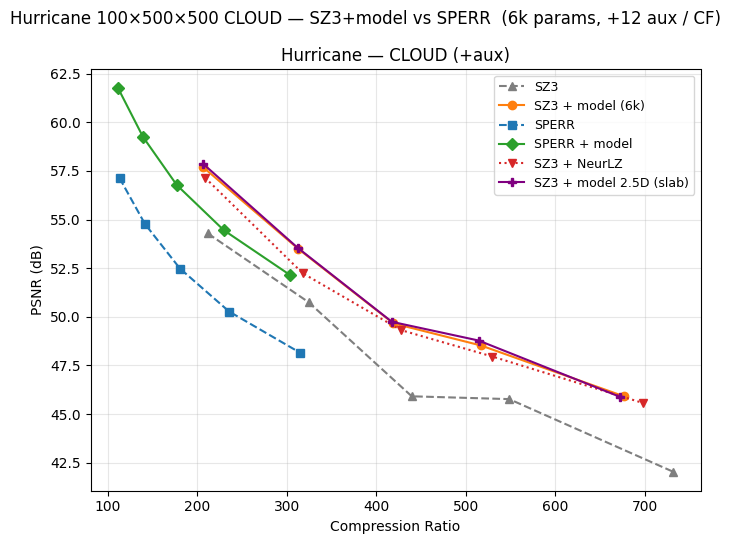

Saved: sperr_cmp_hurricane.png


In [4]:
HUR_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/100x500x500/"
HUR_SHAPE = (100, 500, 500)
HUR_TARGET = "CLOUDf48"
HUR_AUX    = [ "Vf48",  "TCf48",
               "Uf48", "PRECIPf48", "Wf48"]   # all 5 non-target fields (CF mode)
HUR_REL    = [1e-2, 2e-2, 3e-2, 4e-2, 6e-2]
HUR_PARAMS, HUR_EPOCHS = 6500, 100

tgt = np.fromfile(HUR_DIR + HUR_TARGET + ".bin.f32", dtype=np.float32).reshape(HUR_SHAPE)
aux = [np.memmap(HUR_DIR + a + ".bin.f32", dtype=np.float32, mode="r", shape=HUR_SHAPE)
       for a in HUR_AUX]
r = bench_field("Hurricane/CLOUD", tgt, HUR_DIR + HUR_TARGET + ".bin.f32", aux, HUR_SHAPE,
                HUR_REL, HUR_PARAMS, HUR_EPOCHS,
                full_slice=True, full_slice_axis=0)   # slice along z (axis 0) -> full 500x500 xy-planes (xyz/yxz order)
del tgt, aux
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r, "Hurricane — CLOUD (+aux)")
fig.suptitle("Hurricane 100×500×500 CLOUD — SZ3+model vs SPERR  (6k params, +12 aux / CF)", fontsize=12)
plt.tight_layout()
plt.savefig("sperr_cmp_hurricane.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_hurricane.png")

### Hurricane — NO aux (single-field): my pipeline vs NeurLZ head-to-head
Same target/rels/budget/epochs as above, but **`aux=[]`** so the BG model also sees only CLOUD (`in_channels=1`) — a like-for-like single-field comparison against NeurLZ (which is already single-field).

In [ ]:
# ── Hurricane CLOUD — NO aux: BG pipeline AND NeurLZ both single-field ─────────
# aux=[] -> the BG model sees only CLOUD (in_channels=1), head-to-head vs NeurLZ.
# (Reuses HUR_* from the cell above; reload tgt since that cell deletes it.)
tgt = np.fromfile(HUR_DIR + HUR_TARGET + ".bin.f32", dtype=np.float32).reshape(HUR_SHAPE)
set_seed(SEED)
r_hur_noaux = bench_field("Hurricane/CLOUD (no aux)", tgt, HUR_DIR + HUR_TARGET + ".bin.f32", [],
                          HUR_SHAPE, HUR_REL, HUR_PARAMS, HUR_EPOCHS,
                          full_slice=True, full_slice_axis=0)   # slice along z (axis 0)
del tgt
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r_hur_noaux, "Hurricane — CLOUD (no aux)")
fig.suptitle("Hurricane 100×500×500 CLOUD (NO aux) — SZ3+model vs SPERR  (6k params)", fontsize=12)
plt.tight_layout()
plt.savefig("sperr_cmp_hurricane_noaux.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_hurricane_noaux.pdf")


## 4. Magnetic Reconnection 512³  —  single field (30k params)

In [ ]:
MAG_FILE  = "/home/sam/Halo_Finder/halo_finder_v1/magnetic_reconnection_512x512x512_float32.raw"
MAG_SHAPE = (512, 512, 512)
MAG_REL   = [1e-3, 3e-3, 5e-3, 7e-3]
MAG_PARAMS, MAG_EPOCHS = 30000, 20

mag = np.fromfile(MAG_FILE, dtype=np.float32).reshape(MAG_SHAPE)
r = bench_field("Magnetic", mag, MAG_FILE, [], MAG_SHAPE, MAG_REL, MAG_PARAMS, MAG_EPOCHS)
del mag
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r, "Magnetic Reconnection 512³ — single field")
fig.suptitle("Magnetic Reconnection 512³ — SZ3+model vs SPERR  (30k params)", fontsize=12)
plt.tight_layout()
plt.savefig("sperr_cmp_magnetic.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_magnetic.pdf")

WPX


[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Total Params: 4,444
 [Params] Main (BG) Network : 4,444 parameters

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters

[Model: spatial] Total Params: 6,814
 [Params] Main (BG) Network : 6,814 parameters

[Model: spatial] Total Params: 8,188
 [Params] Main (BG) Network : 8,188 parameters

[Model: spatial] Total Params: 9,688
 [Params] Main (BG) Network : 9,688 parameters

[Model: spatial] Total Params: 11,314
 [Params] Main (BG) Network : 11,314 parameters

[Model: spatial] Total Params: 13,066
 [Params] Main (BG) Network 

/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


  [BO] band=1.0e-02 axis1: 32x2048x256 patch256 base=51.28 -> lr=3e-03 proxy=54.05 gain=+2.77 | 1e-04:51.3 1e-04:51.3 2e-04:51.4 3e-04:51.4 5e-04:51.6 7e-04:52.1 1e-03:52.7 1e-03:53.2 2e-03:53.4 3e-03:54.0
  [BO] => PICK axis1 (depth=256; near-best { 1:256 }) lr=3.0e-03 gain=+2.77

[Model: spatial] Total Params: 28,858
 [Params] Main (BG) Network : 28,858 parameters
[Init] Epoch   0 | Global PSNR: 51.62 dB | MaxErr: 0.0
[plan] pure_train_budget=1000000000.00s | epochs_cap=20 | steps/epoch=256 | patch=256 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)
[gpu-sampling] 1 fields resident on cuda:0 (~1.1 GB)
Epoch   1 [BG] | train_wall=1.05s | Loss: 0.985304 | Freq: 0.671535 | Low: 0.226546 | Mid: 0.071924 | High: 0.204643 | Global: 54.11 dB | MaxErr: 0.0  [New Best!]
[timing] first_epoch_pure_train≈1.118s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=1.05s | Loss: 0.877430 | Freq: 0.438534 | Low: 0.

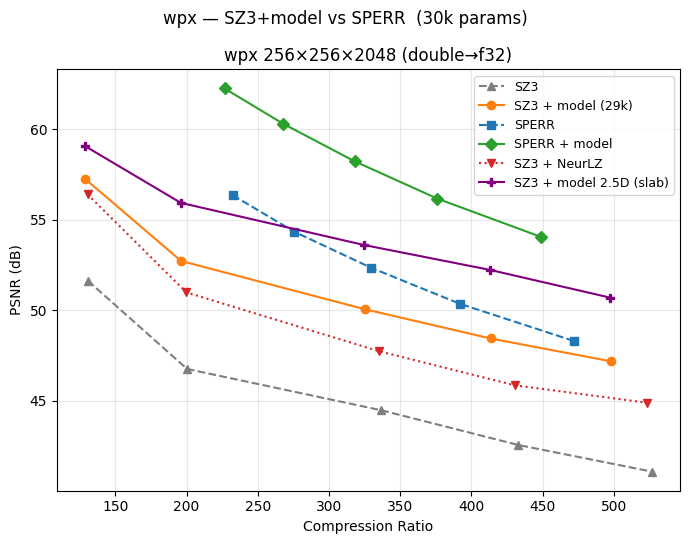

Saved: sperr_cmp_wpx.png


In [4]:
# ── wpx 256×256×2048 (double) ────────────────────────────────────────────────
WPX_RAW       = "/home/sam/Halo_Finder/halo_finder_v1/wpx-256_256_2048_double.raw"
WPX_SRC_SHAPE = (256, 256, 2048)        # as stored (float64)

# double -> float32 (this notebook trains/compresses in f32); reorient so the
# model's 2-D slices are SQUARE (256×256): move the 2048 axis to depth.
_wpx = np.fromfile(WPX_RAW, dtype=np.float64).reshape(WPX_SRC_SHAPE).astype(np.float32)
_wpx = np.ascontiguousarray(np.transpose(_wpx, (2, 0, 1)))   # -> (2048, 256, 256)
WPX_SHAPE = _wpx.shape

# SPERR reads a file with --ftype 32, so write the reoriented f32 volume for it
WPX_F32 = "/tmp/wpx_2048_256_256_f32.raw"
_wpx.tofile(WPX_F32)

WPX_REL              = [1e-2, 2e-2, 3e-2, 4e-2, 5e-2]
WPX_PARAMS, WPX_EPOCHS = 30000, 20        # depth=2048 → epochs are ~4× Magnetic; lower if slow

set_seed(SEED)
r = bench_field("wpx", _wpx, WPX_F32, [], WPX_SHAPE, WPX_REL, WPX_PARAMS, WPX_EPOCHS, full_slice=True, full_slice_axis=1)
del _wpx
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r, "wpx 256×256×2048 (double→f32)")
fig.suptitle("wpx — SZ3+model vs SPERR  (30k params)", fontsize=12)
plt.tight_layout()
plt.savefig("sperr_cmp_wpx.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_wpx.png")


In [ ]:
# # ====================================================================================
# # Per-dataset RESIDUAL distributions: raw R=X-X' | after minmax | after zscore
# # R (the SZ3 error) is the model's TARGET / what it predicts; minmax & zscore are the two
# # ways it gets normalized before the loss. Needs SZ3 (compress+decompress) per dataset at
# # a representative rel. Miranda peaks ~8 GB (x + X'); comment it out if RAM is tight.
# # Residual stats are TRUE (chunked); a ~2M subsample is used for the histograms.
# # ====================================================================================
# import numpy as np, matplotlib.pyplot as plt, os
# from pysz import SZ
# _sz_eng = SZ(globals().get("sz_lib_path", "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"))
# _NYX = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"

# # (label, path, raw_dtype, shape, rel)
# RES_DATASETS = [
#     ("NYX/baryon_density",      _NYX + "baryon_density.f32",      np.float32, (512, 512, 512), 1e-4),
#     ("NYX/dark_matter_density", _NYX + "dark_matter_density.f32", np.float32, (512, 512, 512), 1e-4),
#     ("NYX/temperature",         _NYX + "temperature.f32",        np.float32, (512, 512, 512), 1e-4),
#     ("Hurricane/CLOUDf48", "/home/sam/Halo_Finder/halo_finder_v1/100x500x500/CLOUDf48.bin.f32",              np.float32, (100, 500, 500),    1e-3),
#     ("Magnetic",           "/home/sam/Halo_Finder/halo_finder_v1/magnetic_reconnection_512x512x512_float32.raw", np.float32, (512, 512, 512), 1e-3),
#     ("wpx",                "/home/sam/Halo_Finder/halo_finder_v1/wpx-256_256_2048_double.raw",               np.float64, (256, 256, 2048),   1e-3),
#     ("Miranda",            "/home/sam/Halo_Finder/halo_finder_v1/miranda_1024x1024x1024_float32.raw",        np.float32, (1024, 1024, 1024), 1e-3),
# ]

# def _resid_stats_sample(x, xp, n_sample=2_000_000, chunk=8_000_000):
#     n = x.size; xf = x.ravel(); xpf = xp.ravel()
#     s = ss = 0.0; vmin = np.inf; vmax = -np.inf
#     stride = max(1, n // n_sample); samp = []
#     for i in range(0, n, chunk):
#         rc = xf[i:i+chunk].astype(np.float64) - xpf[i:i+chunk].astype(np.float64)
#         s += rc.sum(); ss += (rc*rc).sum()
#         vmin = min(vmin, rc.min()); vmax = max(vmax, rc.max()); samp.append(rc[::stride])
#     mean = s/n; std = max(ss/n - mean*mean, 0.0) ** 0.5
#     return vmin, vmax, mean, std, np.concatenate(samp)

# avail = [r for r in RES_DATASETS if os.path.exists(r[1])]
# nrow = len(avail)
# fig, axes = plt.subplots(nrow, 3, figsize=(14, 2.6 * nrow), dpi=120)
# axes = np.atleast_2d(axes)
# for r, (label, path, dt, shape, rel) in enumerate(avail):
#     x = np.ascontiguousarray(np.fromfile(path, dtype=dt).reshape(shape).astype(np.float32))
#     b, _ = _sz_eng.compress(x, 1, 0, float(rel), 0)
#     xp = _sz_eng.decompress(b, x.shape, np.float32)
#     vmin, vmax, mean, std, R = _resid_stats_sample(x, xp)
#     del x, xp, b
#     rng = (vmax - vmin) or 1.0

#     ax = axes[r, 0]                                   # raw residual, log-y
#     ax.hist(R, bins=120, color="0.5"); ax.set_yscale("log")
#     ax.set_ylabel(f"{label}\nrel={rel:.0e}", fontsize=8)
#     if r == 0: ax.set_title("raw residual  R = X - X'")
#     ax.text(0.97, 0.93, f"min={vmin:.1e}  max={vmax:.1e}\nμ={mean:.1e}  σ={std:.1e}",
#             transform=ax.transAxes, ha="right", va="top", fontsize=7)

#     ax = axes[r, 1]                                   # minmax residual in [0,1], log-y
#     ax.hist((R - vmin) / rng, bins=120, range=(0, 1), color="tab:red"); ax.set_yscale("log")
#     if r == 0: ax.set_title("residual after minmax")
#     ax.text(0.97, 0.93, f"bulk σ={std/rng:.2e}\nmean@{(mean-vmin)/rng:.2f}",
#             transform=ax.transAxes, ha="right", va="top", fontsize=7)

#     ax = axes[r, 2]                                   # zscore residual (full, bounded), log-y
#     ax.hist((R - mean) / std, bins=120, color="tab:blue"); ax.set_yscale("log")
#     if r == 0: ax.set_title("residual after zscore  (units of σ)")
#     ax.text(0.97, 0.93, f"max={(vmax-mean)/std:.1f}σ\nmin={(vmin-mean)/std:.1f}σ",
#             transform=ax.transAxes, ha="right", va="top", fontsize=7)

# fig.suptitle("Per-dataset RESIDUAL (X - X') distributions:  raw  |  minmax  |  zscore", y=1.001, fontsize=12)
# fig.tight_layout()
# plt.show()



[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Total Params: 4,444
 [Params] Main (BG) Network : 4,444 parameters

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters

[Model: spatial] Total Params: 6,814
 [Params] Main (BG) Network : 6,814 parameters

[Model: spatial] Total Params: 8,188
 [Params] Main (BG) Network : 8,188 parameters

[Model: spatial] Total Params: 9,688
 [Params] Main (BG) Network : 9,688 parameters

[Model: spatial] Total Params: 11,314
 [Params] Main (BG) Network : 11,314 parameters

[Model: spatial] Total Params: 13,066
 [Params] Main (BG) Network 

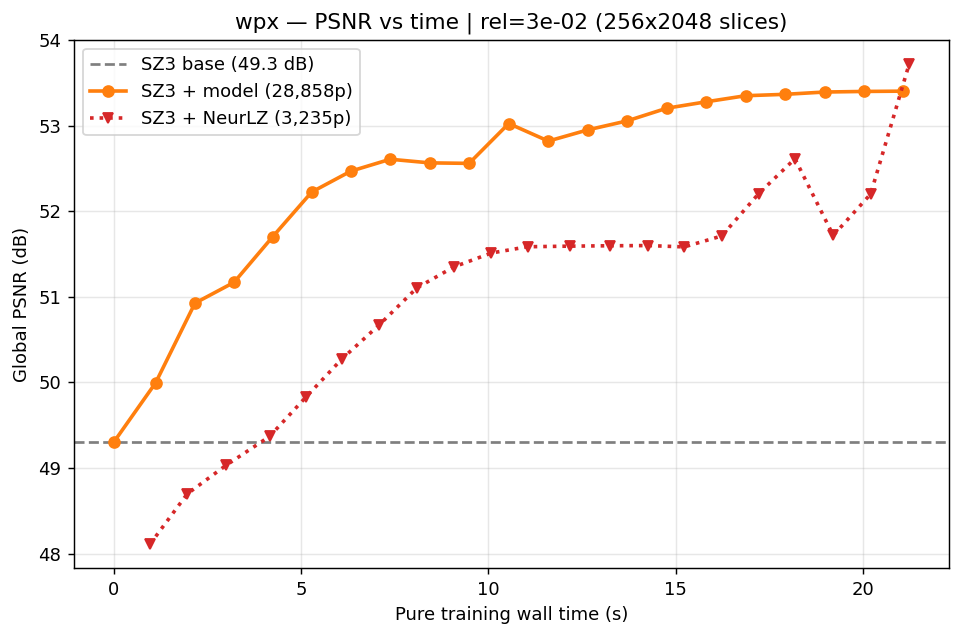

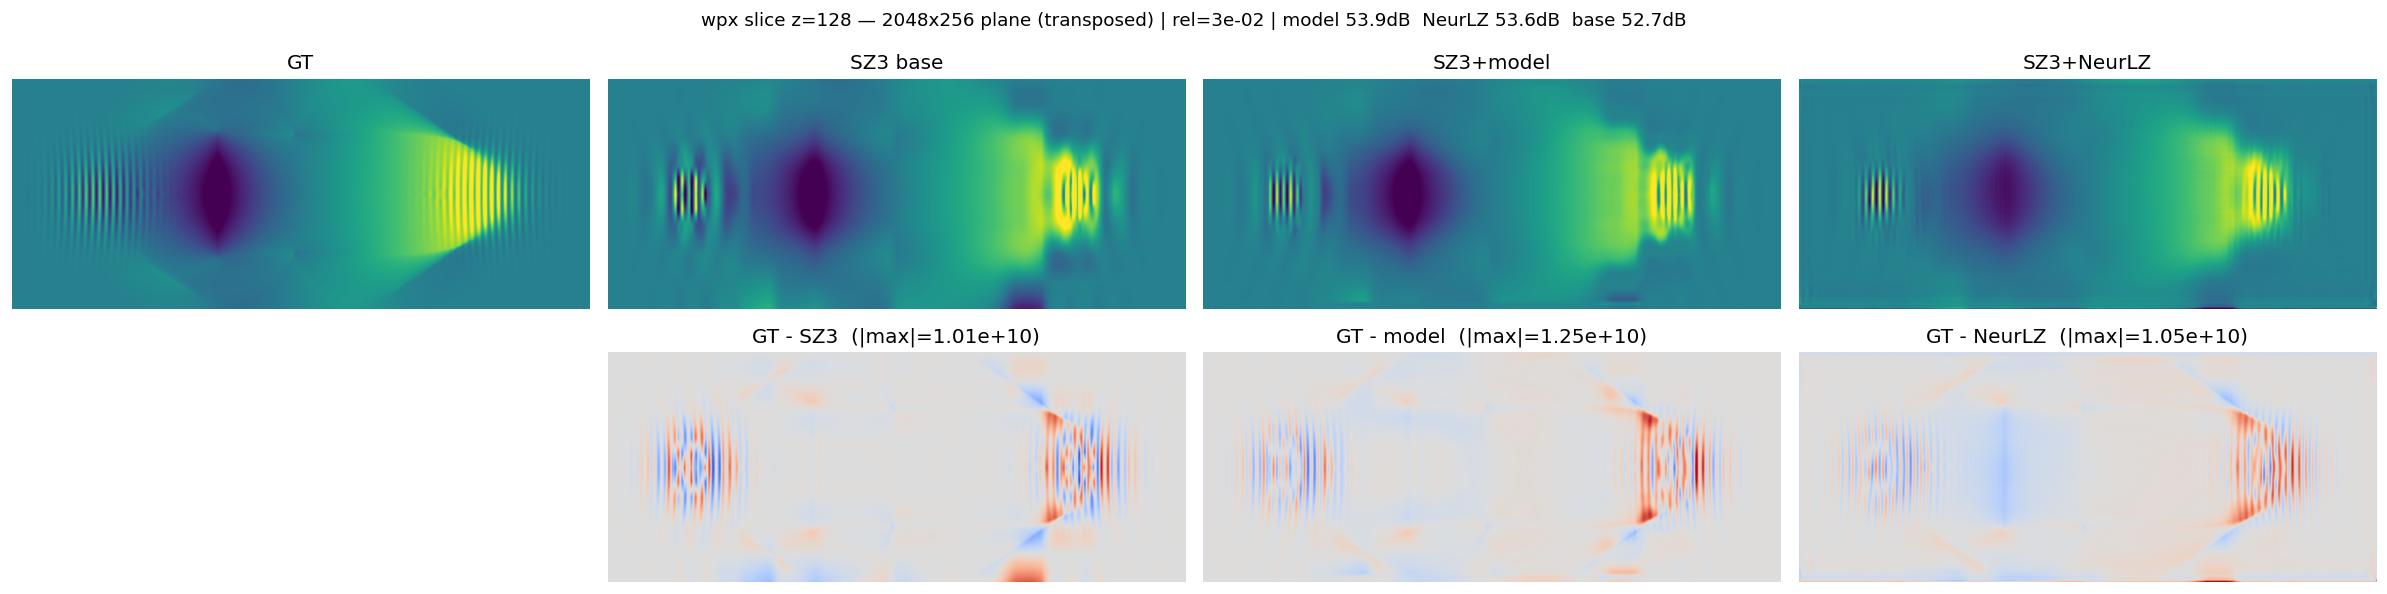

In [5]:
# ── wpx: NeurLZ vs BG pipeline — PSNR-vs-time + slice viz (one rel) ────────────
# Re-trains BOTH on a single wpx rel (full 256x2048 planes, slice axis 1), capturing
# per-epoch (pure-train-time, PSNR) and the final reconstruction, then plots:
#   (1) PSNR vs wall time   (2) a 2048x256 slice: GT / SZ3 / SZ3+model / SZ3+NeurLZ + residuals
import matplotlib.pyplot as plt
WPX_VIZ_REL = WPX_REL[2]          # which rel to visualize
_PERM = (1, 0, 2)                 # axis1 -> front (self-inverse); planes become (2048, 256)

# reload wpx (the bench cell deletes _wpx) + SZ3 base at the viz rel
_wx = np.ascontiguousarray(np.fromfile(WPX_RAW, dtype=np.float64).reshape((2048, 256, 256)).astype(np.float32))
_dr = float(_wx.max() - _wx.min())
_b, _ = sz_engine.compress(_wx, 1, 0, float(WPX_VIZ_REL), 0)
_xq = sz_engine.decompress(_b, _wx.shape, np.float32)

# ---- BG pipeline (full-slice along axis 1 -> 2048x256 planes) ----
Xs_bg  = [np.ascontiguousarray(np.transpose(_wx,  _PERM))]   # (256, 2048, 256)
Xps_bg = [np.ascontiguousarray(np.transpose(_xq, _PERM))]
_bgh = bg_h_for_params(WPX_PARAMS, _wx.shape, 1)
_np, _ = estimate_bg_model_param_bytes(n_fields=1, shape=_wx.shape, bg_arch="spatial", bg_h=_bgh,
                                       dtype_bytes=BYTES_PER_PARAM)
_cfg = build_bg_only_cfg(X_target=Xs_bg[0], Xps=Xps_bg, max_train_time=1e9, bg_h=_bgh, roi_h=4,
                         epochs=WPX_EPOCHS, steps_per_epoch=Xs_bg[0].shape[0], bg_patch_size=256,
                         bg_batch=1, lr=1e-3, bg_freq_weight=0.5, bg_fft_phase_weight=0.5,
                         bg_freq_warmup_epochs=1, bg_field_norm="zscore")
_cfg.bg_arch="spatial"; _cfg.bg_split_mode="three"; _cfg.bg_split_bands=True
_cfg.bg_split_sigma=0.12; _cfg.bg_sigma_low=0.08; _cfg.bg_sigma_mid=0.18
_cfg.bg_cr_rel_err=float(WPX_VIZ_REL); _cfg.bg_gpu_sampling=True; _cfg.seed=SEED
_cfg.bg_full_slice=True; _cfg.bg_low_weight=1.0; _cfg.bg_mid_weight=0.5; _cfg.bg_high_weight=0.3
def _ev(m, c=_cfg):
    return compute_psnr(Xs_bg[0], run_bg_inference(m, Xs_bg, Xps_bg, c, float(WPX_VIZ_REL)), _dr), 0.0
print(f"[viz] training BG pipeline (rel={WPX_VIZ_REL:.0e}, {_np:,} params)...")
_model, _hist = train_bg_only(Xs=Xs_bg, Xps=Xps_bg, device=device, cfg=_cfg, evaluator=_ev)
bg_t = list(_hist.get("time", []))
bg_p = [(v[1] if isinstance(v, (tuple, list)) else float(v)) for v in _hist.get("psnr", [])]
_m = min(len(bg_t), len(bg_p)); bg_t, bg_p = bg_t[:_m], bg_p[:_m]
xhat_bg = run_bg_inference(_model, Xs_bg, Xps_bg, _cfg, float(WPX_VIZ_REL))   # (256,2048,256)
del _model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# ---- NeurLZ (same slicing axis; iso-time budget = BG's total; returns history + recon) ----
_feat = (_neurlz_features_for_params(_np, 1) if NEURLZ_FEATURES == "match" else NEURLZ_FEATURES)
_budget = bg_t[-1] if bg_t else None
print(f"[viz] training NeurLZ (slice_axis=1, budget={_budget:.1f}s)...")
p_nlz, nlz_params, nlz_time, nlz_ep, nlz_hist, enh_nlz = run_neurlz(
    _wx, _xq, [], _wx.shape, _dr, float(WPX_VIZ_REL),
    int(WPX_EPOCHS * NEURLZ_EPOCH_MULT), _feat, time_budget=_budget, slice_axis=1, return_history=True)
# enh_nlz is in the permuted frame (256,2048,256), same as Xs_bg

base_psnr = compute_psnr(Xs_bg[0], Xps_bg[0], _dr)

# ---- (1) PSNR vs time ----
plt.figure(figsize=(7.5, 5), dpi=130)
plt.axhline(base_psnr, color="tab:gray", ls="--", lw=1.5, label=f"SZ3 base ({base_psnr:.1f} dB)")
plt.plot(bg_t, bg_p, "o-", color="tab:orange", lw=2, label=f"SZ3 + model ({_np:,}p)")
plt.plot(nlz_hist["time"], nlz_hist["psnr"], "v:", color="tab:red", lw=2, label=f"SZ3 + NeurLZ ({nlz_params:,}p)")
plt.xlabel("Pure training wall time (s)"); plt.ylabel("Global PSNR (dB)")
plt.title(f"wpx — PSNR vs time | rel={WPX_VIZ_REL:.0e} (256x2048 slices)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# ---- (2) slice viz: a 2048x256 plane (shown transposed = 256x2048 wide) ----
_z = Xs_bg[0].shape[0] // 2
gt, base, bg, nlz = Xs_bg[0][_z], Xps_bg[0][_z], xhat_bg[_z], enh_nlz[_z]
vmin, vmax = float(np.percentile(gt, 1)), float(np.percentile(gt, 99))
rmax = float(np.max(np.abs(gt - base))) or 1e-9
fig, ax = plt.subplots(2, 4, figsize=(20, 5), dpi=120)
for k, (nm, im) in enumerate([("GT", gt), ("SZ3 base", base), ("SZ3+model", bg), ("SZ3+NeurLZ", nlz)]):
    ax[0, k].imshow(im.T, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax[0, k].set_title(nm); ax[0, k].axis("off")
ax[1, 0].axis("off")
for k, (nm, im) in enumerate([("GT - SZ3", gt - base), ("GT - model", gt - bg), ("GT - NeurLZ", gt - nlz)]):
    a = ax[1, k + 1]; a.imshow(im.T, cmap="coolwarm", vmin=-rmax, vmax=rmax, aspect="auto")
    a.set_title(f"{nm}  (|max|={np.max(np.abs(im)):.2e})"); a.axis("off")
fig.suptitle(f"wpx slice z={_z} — 2048x256 plane (transposed) | rel={WPX_VIZ_REL:.0e} | "
             f"model {compute_psnr(gt,bg,_dr):.1f}dB  NeurLZ {compute_psnr(gt,nlz,_dr):.1f}dB  base {compute_psnr(gt,base,_dr):.1f}dB", fontsize=11)
plt.tight_layout(); plt.show()
del _wx, _xq, Xs_bg, Xps_bg, xhat_bg, enh_nlz
torch.cuda.empty_cache() if torch.cuda.is_available() else None


                dataset       sub_shape   rel  corr_ax0  corr_ax1  corr_ax2  cross_slice  in_plane  ratio           slab_verdict
     NYX/baryon_density (384, 384, 384) 0.000     0.588     0.554     0.540        0.588     0.547  1.074    no gain (redundant)
        NYX/temperature (384, 384, 384) 0.000     0.541     0.493     0.475        0.541     0.484  1.118    no gain (redundant)
NYX/dark_matter_density (384, 384, 384) 0.000     0.373     0.371     0.347        0.373     0.359  1.039    no gain (redundant)
                Miranda (384, 384, 384) 0.001     0.397     0.325     0.323        0.397     0.324  1.224               marginal
               Magnetic (384, 384, 384) 0.001     0.185     0.202     0.217        0.185     0.210  0.883    no gain (redundant)
                    wpx (384, 256, 256) 0.010     0.815     0.299     0.422        0.815     0.360  2.262 helps (axis-0 context)


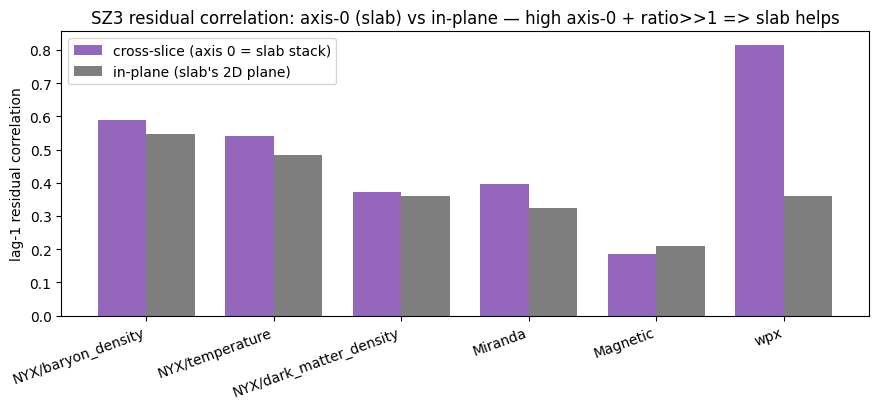

Saved: sperr_slab_residual_corr.pdf


In [6]:
# ============================================================================
# Why does the 2.5D slab help wpx but not NYX / Miranda / Magnetic Reconnection?
# ----------------------------------------------------------------------------
# KEY: the slab block always stacks its K neighbor slices along AXIS 0 (depth) for
# every dataset (it does NOT use full_slice_axis). So the slab only helps when the
# SZ3 residual R = X - X' is more correlated along AXIS 0 than within the slab's own
# (axis1, axis2) plane -- that is the new context the plain 2D model can't see.
# We report the lag-1 Pearson correlation of R along each axis, then:
#   * cross-slice = corr along axis 0           (the slab's stacking axis)
#   * in-plane    = mean corr along axes 1, 2   (the slab's 2D plane)
#   * ratio       = cross / in-plane.  High cross AND ratio >> 1  =>  slab helps.
# Note: wpx is reoriented to (2048,256,256) exactly as the bench loads it, so axis 0
# is the long, smooth beam-propagation direction. Measured on a centered sub-cube.
NYX_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"
NYX_SHAPE = (512, 512, 512)
NYX_ALL   = ["baryon_density", "dark_matter_density", "temperature",
             "velocity_x", "velocity_y", "velocity_z"]
NYX_TARGETS = ["baryon_density", "temperature", "dark_matter_density"]
# Per-field rel_err: baryon density needs much tighter bounds than temperature /
# dark matter density (different dynamic ranges / compressibility).
NYX_REL = {
    "baryon_density":      [1e-6, 3e-6, 5e-6, 7e-6, 9e-6],
    "temperature":         [1e-4, 3e-4, 5e-4, 7e-4, 9e-4],
    "dark_matter_density": [1e-4, 3e-4, 5e-4, 7e-4, 9e-4],
}
NYX_PARAMS, NYX_EPOCHS, NYX_SPERR_OFF = 30000, 20, 20.0
NYX_SPERR_EXTRA_SPAN, NYX_SPERR_NEXTRA = 8.0, 0   # 5 rel + 2 extra = 7 SPERR points

MIR_FILE  = "/home/sam/Halo_Finder/halo_finder_v1/miranda_1024x1024x1024_float32.raw"
MIR_SHAPE = (1024, 1024, 1024)
MIR_REL   = [1e-3, 3e-3, 5e-3, 7e-3, 9e-3]
MIR_PARAMS, MIR_EPOCHS = 240000, 10


HUR_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/100x500x500/"
HUR_SHAPE = (100, 500, 500)
HUR_TARGET = "CLOUDf48"
HUR_AUX    = ["PRECIPf48", "Pf48", "TCf48", "Uf48", "Vf48", "Wf48"]
HUR_REL    = [1e-3, 2e-3, 3e-3, 4e-3, 6e-3]
HUR_PARAMS, HUR_EPOCHS = 6000, 20

MAG_FILE  = "/home/sam/Halo_Finder/halo_finder_v1/magnetic_reconnection_512x512x512_float32.raw"
MAG_SHAPE = (512, 512, 512)
MAG_REL   = [1e-3, 3e-3, 5e-3, 7e-3]
MAG_PARAMS, MAG_EPOCHS = 30000, 20


# ── wpx 256×256×2048 (double) ────────────────────────────────────────────────
WPX_RAW       = "/home/sam/Halo_Finder/halo_finder_v1/wpx-256_256_2048_double.raw"
WPX_SRC_SHAPE = (256, 256, 2048)        # as stored (float64)

# double -> float32 (this notebook trains/compresses in f32); reorient so the
# model's 2-D slices are SQUARE (256×256): move the 2048 axis to depth.
_wpx = np.fromfile(WPX_RAW, dtype=np.float64).reshape(WPX_SRC_SHAPE).astype(np.float32)
_wpx = np.ascontiguousarray(np.transpose(_wpx, (1, 0, 2)))   # -> (2048, 256, 256)
WPX_SHAPE = _wpx.shape

# SPERR reads a file with --ftype 32, so write the reoriented f32 volume for it
WPX_F32 = "/tmp/wpx_2048_256_256_f32.raw"
_wpx.tofile(WPX_F32)

WPX_REL              = [1e-2, 2e-2, 3e-2, 4e-2, 5e-2]
WPX_PARAMS, WPX_EPOCHS = 30000, 20     


import numpy as np, pandas as pd

CORR_CROP = 384   # centered sub-cube side used for the residual-correlation probe
SLAB_AXIS = 0     # the slab2d path stacks neighbor slices along this axis for all datasets

def _lag1_corr(R, ax):
    a = np.moveaxis(R, ax, 0)
    x = a[:-1].reshape(-1).astype(np.float64); y = a[1:].reshape(-1).astype(np.float64)
    xs, ys = x.std(), y.std()
    if xs < 1e-12 or ys < 1e-12:
        return float("nan")
    return float(((x - x.mean()) * (y - y.mean())).mean() / (xs * ys))

def _residual_corr(name, vol, rel, crop=CORR_CROP):
    sl = tuple(slice((d - min(crop, d)) // 2, (d - min(crop, d)) // 2 + min(crop, d)) for d in vol.shape)
    sub = np.ascontiguousarray(np.asarray(vol[sl], np.float32))
    b, _ = sz_engine.compress(sub, 1, 0, float(rel), 0)
    R = sub - sz_engine.decompress(b, sub.shape, np.float32)
    corrs = [_lag1_corr(R, ax) for ax in range(3)]
    cross = corrs[SLAB_AXIS]
    inplane = float(np.nanmean([corrs[ax] for ax in range(3) if ax != SLAB_AXIS]))
    return dict(dataset=name, sub_shape=tuple(sub.shape), rel=float(rel),
                corr_ax0=corrs[0], corr_ax1=corrs[1], corr_ax2=corrs[2],
                cross_slice=cross, in_plane=inplane,
                ratio=(cross / inplane if inplane else float("nan")))

_rows = []
# --- NYX — 3 targets at their tightest rel
for _t in ["baryon_density", "temperature", "dark_matter_density"]:
    _v = np.memmap(NYX_DIR + _t + ".f32", dtype=np.float32, mode="r", shape=NYX_SHAPE)
    _rows.append(_residual_corr(f"NYX/{_t}", _v, NYX_REL[_t][0])); del _v
# --- Miranda
_v = np.memmap(MIR_FILE, dtype=np.float32, mode="r", shape=MIR_SHAPE)
_rows.append(_residual_corr("Miranda", _v, MIR_REL[0])); del _v
# --- Magnetic Reconnection
_v = np.memmap(MAG_FILE, dtype=np.float32, mode="r", shape=MAG_SHAPE)
_rows.append(_residual_corr("Magnetic", _v, MAG_REL[0])); del _v
# --- wpx: reorient to (2048,256,256) (axis 0 = beam axis), exactly as the bench does
_v = np.memmap(WPX_RAW, dtype=np.float64, mode="r", shape=WPX_SRC_SHAPE)
_v = np.ascontiguousarray(np.transpose(_v, (2, 0, 1)).astype(np.float32))
_rows.append(_residual_corr("wpx", _v, WPX_REL[0])); del _v

corr_df = pd.DataFrame(_rows)
corr_df["slab_verdict"] = np.where(corr_df["ratio"] >= 1.5, "helps (axis-0 context)",
                          np.where(corr_df["ratio"] >= 1.15, "marginal", "no gain (redundant)"))
pd.set_option("display.width", 170, "display.max_columns", 20)
print(corr_df[["dataset", "sub_shape", "rel", "corr_ax0", "corr_ax1", "corr_ax2",
               "cross_slice", "in_plane", "ratio", "slab_verdict"]].round(3).to_string(index=False))

# bar: cross-slice (axis 0) vs in-plane residual correlation per dataset
fig, ax = plt.subplots(figsize=(9, 4.2))
xpos = np.arange(len(corr_df)); w = 0.38
ax.bar(xpos - w/2, corr_df["cross_slice"], w, label="cross-slice (axis 0 = slab stack)", color="tab:purple")
ax.bar(xpos + w/2, corr_df["in_plane"],   w, label="in-plane (slab's 2D plane)",         color="tab:gray")
ax.set_xticks(xpos); ax.set_xticklabels(corr_df["dataset"], rotation=20, ha="right")
ax.set_ylabel("lag-1 residual correlation"); ax.axhline(0, color="k", lw=0.6)
ax.set_title("SZ3 residual correlation: axis-0 (slab) vs in-plane — high axis-0 + ratio>>1 => slab helps")
ax.legend(); plt.tight_layout(); plt.savefig("sperr_slab_residual_corr.pdf", bbox_inches="tight"); plt.show()
print("Saved: sperr_slab_residual_corr.pdf")
